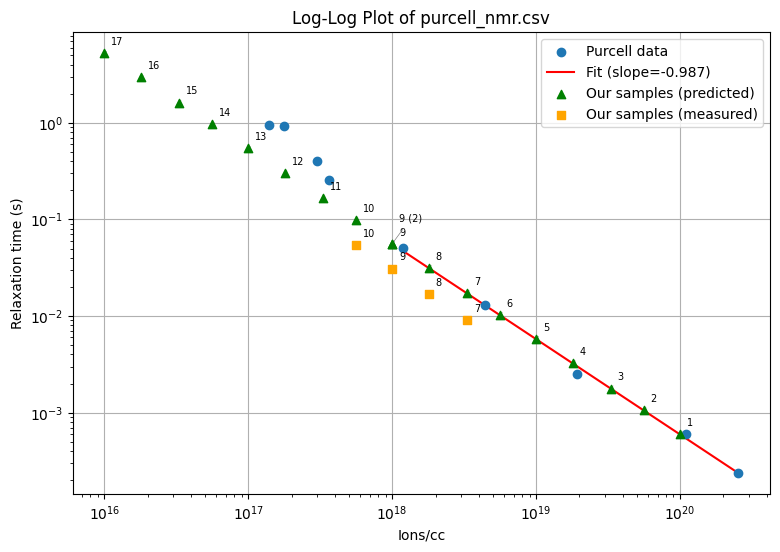

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
data = pd.read_csv('purcell_nmr.csv', header=None)

x = data[0].values.astype(float)
y = data[1].values.astype(float)

# Linear fit in log-log space, excluding first 4 points (smallest x)
idx = np.argsort(x)
x_sorted, y_sorted = x[idx], y[idx]
x_fit, y_fit = x_sorted[4:], y_sorted[4:]

coeffs = np.polyfit(np.log10(x_fit), np.log10(y_fit), 1)
slope, intercept = coeffs

x_line = np.logspace(np.log10(x_fit[0]), np.log10(x_fit[-1]), 300)
y_line = 10**intercept * x_line**slope

# Load sample predictions
samples = pd.read_csv('NMR Data - Concentrations.csv')
sample_nums = samples['Sample Number'].values
ions = samples['# ions/cc'].values.astype(float)
predicted_T = 10**(slope * np.log10(ions) + intercept)

# Load measured data
measured = pd.read_csv('nmr_data_collected.csv')
m_ions = measured['ions/cc'].values.astype(float)
m_tau = measured['tau(s)'].values.astype(float)
m_samples = measured['Sample'].values

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, label='Purcell data', zorder=3)
ax.plot(x_line, y_line, color='red', label=f'Fit (slope={slope:.3f})')
ax.scatter(ions, predicted_T, color='green', marker='^', label='Our samples (predicted)', zorder=4)
ax.scatter(m_ions, m_tau, color='orange', marker='s', label='Our samples (measured)', zorder=5)

# Label each point, stacking labels vertically when x-values coincide
x_offsets = {}
for sn, xi, ti in zip(sample_nums, ions, predicted_T):
    key = round(np.log10(xi), 6)
    count = x_offsets.get(key, 0)
    x_offsets[key] = count + 1
    y_offset = 6 + count * 10
    ax.annotate(str(sn), (xi, ti),
                textcoords='offset points', xytext=(5, y_offset),
                fontsize=7, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

for sn, xi, ti in zip(m_samples, m_ions, m_tau):
    ax.annotate(str(sn), (xi, ti),
                textcoords='offset points', xytext=(5, 6),
                fontsize=7, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Ions/cc')
ax.set_ylabel('Relaxation time (s)')
ax.set_title('Log-Log Plot of purcell_nmr.csv')
ax.legend()
ax.grid(True)
plt.show()


In [4]:
import pandas as pd
import numpy as np

samples = pd.read_csv('NMR Data - Concentrations.csv')
sample_nums = samples['Sample Number'].values
ions = samples['# ions/cc'].values.astype(float)

# Predict relaxation time using log-log linear fit: log10(y) = slope*log10(x) + intercept
predicted_T = 10**(slope * np.log10(ions) + intercept)

print(f"{'Sample':<10} {'Ions/cc':>20} {'Predicted T (ms)':>18}")
print("-" * 50)
for sn, xi, ti in zip(sample_nums, ions, predicted_T):
    print(f"{str(sn):<10} {xi:>20.4e} {ti*1000:>18.4e}")


Sample                  Ions/cc   Predicted T (ms)
--------------------------------------------------
1                    9.9968e+19         5.9453e-01
2                    5.5982e+19         1.0536e+00
3                    3.2989e+19         1.7754e+00
4                    1.7994e+19         3.2291e+00
5                    9.9968e+18         5.7674e+00
6                    5.5982e+18         1.0220e+01
7                    3.2989e+18         1.7223e+01
8                    1.7994e+18         3.1324e+01
9                    9.9968e+17         5.5949e+01
9 (2)                9.9968e+17         5.5949e+01
10                   5.5982e+17         9.9147e+01
11                   3.2989e+17         1.6708e+02
12                   1.7994e+17         3.0387e+02
13                   9.9968e+16         5.4275e+02
14                   5.5982e+16         9.6181e+02
15                   3.2989e+16         1.6208e+03
16                   1.7994e+16         2.9478e+03
17                   9.9968e+15